In [1]:
from dataset.ohlcv.repository import read_df_aapl
from feature.closes.derive import derive_closes_n4

df_aapl = read_df_aapl()
closes_n4 = derive_closes_n4(df_aapl)
closes_n4

Date,now,lag_1,lag_2,lag_3,lag_4
datetime[μs],f64,f64,f64,f64,f64
2015-03-05 00:00:00,-167.095474,-63.590753,20.893798,48.922637,-151.025682
2015-03-06 00:00:00,15.019172,-167.095474,-63.590753,20.893798,48.922637
2015-03-09 00:00:00,42.563318,15.019172,-167.095474,-63.590753,20.893798
2015-03-10 00:00:00,-209.028075,42.563318,15.019172,-167.095474,-63.590753
2015-03-11 00:00:00,-183.997085,-209.028075,42.563318,15.019172,-167.095474
…,…,…,…,…,…
2025-02-19 00:00:00,16.348555,-5.316213,126.305343,194.822215,181.052465
2025-02-20 00:00:00,39.127827,16.348555,-5.316213,126.305343,194.822215
2025-02-21 00:00:00,-11.396476,39.127827,16.348555,-5.316213,126.305343


In [ ]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 特徴量とターゲットの分割（to_pandas()で変換）
X = closes_n4[['lag_1', 'lag_2', 'lag_3', 'lag_4']].to_pandas()
y = closes_n4['now'].to_numpy()  # numpy配列に変換

# 時系列を考慮したデータ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# LightGBM用データセット作成（labelをnumpy配列で指定）
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 回帰用パラメータ設定
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# モデル訓練
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(20)]
)

# 予測と評価
y_pred = np.asarray(model.predict(X_test))  # numpy配列に明示的に変換
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse:.4f}')

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 135.809
Test RMSE: 135.8094


In [3]:
print(y_pred)
print(y_pred.shape)

[ -0.59626332  -8.03309243   9.73486833  12.22670496  -8.03309243
   9.73486833  12.23391922 -11.57157675   9.53170204  -0.92936956
  18.17195234  -8.03309243  10.3724333   -0.59626332  10.61946126
   4.76810587   6.10113562   5.75163365   3.69633225  -2.09862092
  -0.92936956   9.54900692  -8.03309243   9.73486833  16.12726347
  -0.59626332  12.26682736   3.69633225   4.76810587   9.73486833
   9.73486833   9.54900692   7.30567511  18.66708743   3.78157714
   3.15668761  10.90699176  11.96830491   6.90918685   6.90918685
   9.73486833   9.73486833   5.84261405  -0.33053592   9.54900692
 -11.57157675  14.52803168  11.96830491   9.73486833   9.73486833
   3.78157714   3.15668761  10.61946126  11.96830491   9.54900692
  10.55573186   9.73486833   9.73486833  -0.59626332   9.73486833
   3.69633225  -2.09862092   3.97722545   9.73486833  12.22670496
 -11.57157675   3.69633225   4.76810587   9.73486833   6.10113562
  -2.09862092   9.73486833   9.73486833  -0.59626332   9.54900692
  10.61946

MAE: 100.06
R2 Score: 0.00


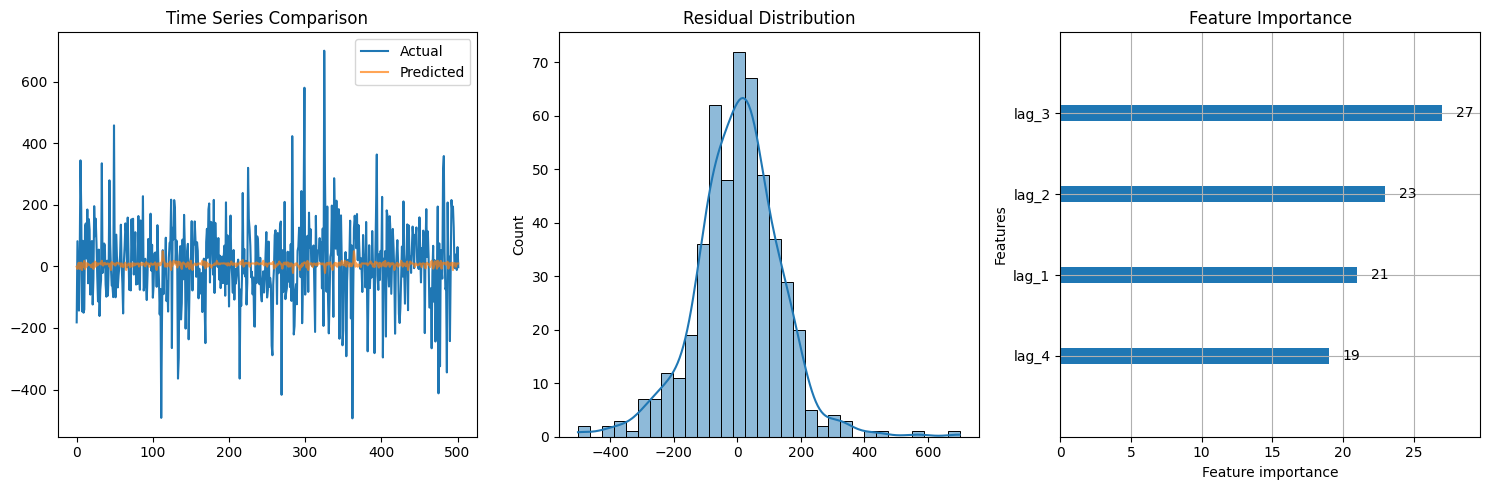

In [4]:
# 追加の評価指標
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. 実際値 vs 予測値の時系列プロット
plt.subplot(1, 3, 1)
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Time Series Comparison')
plt.legend()

# 2. 残差プロット
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, kde=True)
plt.title('Residual Distribution')

# 3. 特徴量重要度
plt.subplot(1, 3, 3)
lgb.plot_importance(model, max_num_features=10, ax=plt.gca())
plt.title('Feature Importance')

plt.tight_layout()
plt.show()